# MACHINE LEARNING

### Aim
 * To develop a machine learning model that predicts the likelihood of a transaction being fraudulent based on transaction features.
 * To analyse the trade-off between catching as many frauds as possible and minimising false alarms (precision vs. recall).
 * To optimise the model for high precision, reducing the number of legitimate transactions incorrectly flagged as fraud, which is important for maintaining a positive customer experience.

In [26]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.model_selection import train_test_split    
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import precision_recall_curve
import ipywidgets as widgets
from IPython.display import display

### Data Preparation
Loading the credit card transaction dataset and split it into features (X) and the target variable (y). Then dividing the data into training and test sets, making sure the class distribution is preserved using stratification.

In [27]:
# Load the dataset
df = pd.read_csv('../Data/creditcard_subset.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
1,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
2,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
3,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
4,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0


In [28]:
# Prepare features and target
X = df.drop(['Class'], axis=1) # All columns except 'Class' / X (features): columns the model uses to make predictions.
y = df['Class']                # Only the 'Class' column / y (target): the column the model is trying to predict.


In [29]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### Baseline Model Results
A Random Forest classifier is trained using default settings. The classification report and confusion matrix below present the model’s initial performance, serving as a baseline for comparison.

In [30]:
# Train model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


The .predict() method in scikit-learn classifiers uses a default threshold of 0.5 for binary classification:
 * If the model’s predicted probability for Class=1 (fraud) is greater than or equal to 0.5, it predicts fraud.
 * If it’s less than 0.5, it predicts non-fraud.

In [31]:
# Make predictions (class labels)
y_pred = clf.predict(X_test)   

In [32]:
# Make predictions (class labels)
y_pred = clf.predict(X_test)   

In [33]:
# Make predictions (probabilities)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

In [34]:
# Evaluate model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.92      0.65      0.76        17

    accuracy                           1.00     10000
   macro avg       0.96      0.82      0.88     10000
weighted avg       1.00      1.00      1.00     10000

[[9982    1]
 [   6   11]]


### Interpretation for Classification Report
 - Precision (fraud): 0.92 — Of all transactions predicted as fraud, 92% were actually fraud.
 - Recall (fraud): 0.65 — Of all actual frauds, the model caught 65%.
 - F1-score (fraud): 0.76 — Harmonic mean of precision and recall.
 - Support (fraud): 17 — Number of actual fraud cases in your test set.

What Does This Mean?
 * The model is very good at identifying non-fraud (almost perfect).
 * It’s pretty good, but not perfect, at identifying fraud:
     - Out of 17 actual frauds, it caught 11 and missed 6.
     - It only misclassified 1 non-fraud as fraud (very few false alarms).


Possible Improvements
 * Try different models
 * Adjust the probability threshold for higher precision, but recall will drop
 * Create new features that are most important for fraud detection


Now, I want to further reduce false alarms by increasing the classification threshold

In [35]:
# Set a higher threshold for fraud prediction
threshold = 0.8  # Only flag as fraud if probability > 0.8
y_pred_high_precision = (clf.predict_proba(X_test)[:, 1] > threshold).astype(int)

# Evaluate the high-precision model
print("High Precision Model (Threshold = 0.8)")
print(classification_report(y_test, y_pred_high_precision))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_high_precision))


High Precision Model (Threshold = 0.8)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9983
           1       0.80      0.24      0.36        17

    accuracy                           1.00     10000
   macro avg       0.90      0.62      0.68     10000
weighted avg       1.00      1.00      1.00     10000

Confusion Matrix:
[[9982    1]
 [  13    4]]


### High Precision Model Results
To minimise false alarms, I increased the threshold for classifying a transaction as fraud from the default 0.5 to 0.8. This means a transaction is only flagged as fraud if the model is very confident. 

What changed?

Precision for fraud (Class 1): 0.80
When this model predicts fraud, it is correct 80% of the time—so there are fewer false alarms.

Recall for fraud: 0.24
The model only catches 24% of actual frauds (4 out of 17).
This is because with a higher threshold, only the most obvious frauds are flagged.

Trying out an interactive approach to experiment with different thresholds and understand the precision-recall trade-off. 

In [ ]:
# Get predicted probabilities for the positive class (fraud)
y_scores = clf.predict_proba(X_test)[:, 1]

# Define a function to evaluate metrics at different thresholds
def evaluate_threshold(threshold):
    y_pred_threshold = (y_scores > threshold).astype(int)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    cm = confusion_matrix(y_test, y_pred_threshold)
    print(f"Threshold: {threshold:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-score: {f1:.2f}")
    print("Confusion Matrix:")
    print(cm)
    print("-" * 30)

# Try a range of thresholds
thresholds = np.linspace(0.1, 0.9, 9)
for t in thresholds:
    evaluate_threshold(t)


Threshold: 0.10
Precision: 0.62
Recall: 0.76
F1-score: 0.68
Confusion Matrix:
[[9975    8]
 [   4   13]]
------------------------------
Threshold: 0.20
Precision: 0.81
Recall: 0.76
F1-score: 0.79
Confusion Matrix:
[[9980    3]
 [   4   13]]
------------------------------
Threshold: 0.30
Precision: 0.87
Recall: 0.76
F1-score: 0.81
Confusion Matrix:
[[9981    2]
 [   4   13]]
------------------------------
Threshold: 0.40
Precision: 0.86
Recall: 0.71
F1-score: 0.77
Confusion Matrix:
[[9981    2]
 [   5   12]]
------------------------------
Threshold: 0.50
Precision: 0.92
Recall: 0.65
F1-score: 0.76
Confusion Matrix:
[[9982    1]
 [   6   11]]
------------------------------
Threshold: 0.60
Precision: 0.91
Recall: 0.59
F1-score: 0.71
Confusion Matrix:
[[9982    1]
 [   7   10]]
------------------------------
Threshold: 0.70
Precision: 0.88
Recall: 0.41
F1-score: 0.56
Confusion Matrix:
[[9982    1]
 [  10    7]]
------------------------------
Threshold: 0.80
Precision: 0.80
Recall: 0.24
F1-

### Adding Precision-Recall vs Threshold Plot

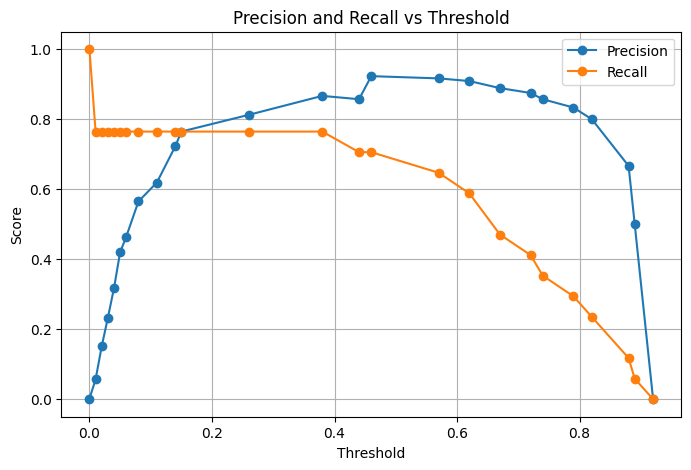

In [37]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', marker='o')
plt.plot(thresholds, recalls[:-1], label='Recall', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Save for Tableau
df.to_csv('creditcard_with_predictions.csv', index=False)
